Answer to [What is wrong in my Taylor series approximation?](https://math.stackexchange.com/questions/5137165/what-is-wrong-in-my-taylor-series-approximation) on math.stackexchange.com

In [1]:
import sympy as sp, numpy as np, matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq

# Define the function symbolically and convert it to a lambda expression
y = sp.symbols('y')
f_sym = sp.cos(2*sp.pi*y) + sp.Rational(1, 20)*sp.sin(60*sp.pi*y)
f = sp.lambdify(y, f_sym, 'numpy')

x = np.linspace(0, 1, 4000, endpoint=False)
b, T = 0.05, 1.0
f_sym

sin(60*pi*y)/20 + cos(2*pi*y)

max |Fehler| = 2.48e-15   (Maschinen-eps ≈ 2.2e-16)


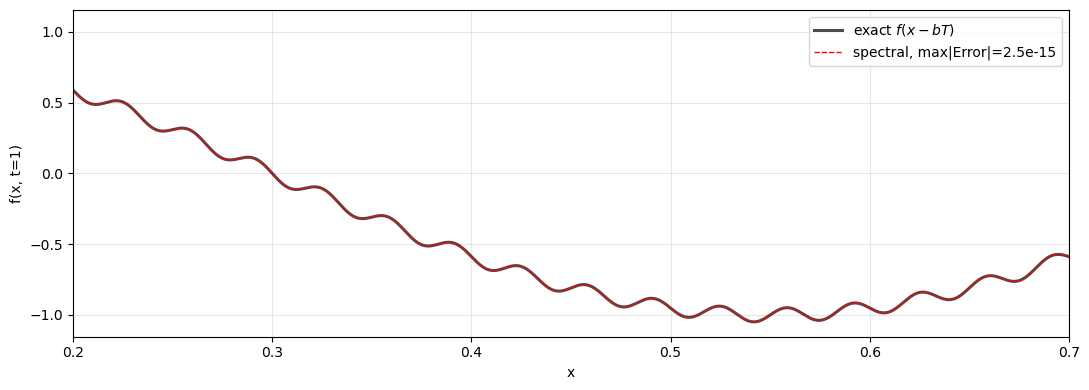

In [4]:
# Spectral Shift:  e^{-bT d/dx} f = IFFT( e^{-i k bT} * FFT(f) )
# = an exactly summable Taylor series, with no convergence issues
k = 2*np.pi * fftfreq(x.size, d=x[1]-x[0])
f_approx = np.real(ifft(np.exp(-1j*k*b*T) * fft(f(x))))
f_exact  = f(x - b*T)

err = np.max(np.abs(f_approx - f_exact))
print(f"max |Fehler| = {err:.2e}   (Maschinen-eps ≈ 2.2e-16)")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(x, f_exact,  'k',  lw=2.2, label='exact $f(x-bT)$', alpha=0.7)
ax.plot(x, f_approx, 'r--', lw=1.0, label=f'spectral, max|Error|={err:.1e}')
ax.set(xlim=(0.2, 0.7), xlabel='x', ylabel='f(x, t=1)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

In [3]:
ax.set_title('');
fig.savefig('shift.png', dpi=150, bbox_inches='tight')